# House Price Prediction with Automated Machine Learning

Accurately predicting house prices is a critical task in real estate analytics, enabling better investment decisions, pricing strategies, and market understanding. In this project, we leverage Automated Machine Learning techniques to build and evaluate multiple regression models on the King County housing dataset.

The dataset contains rich information about properties, including structural features (e.g., square footage, number of bedrooms), location attributes (latitude, longitude, zipcode), and quality indicators (grade, condition, waterfront view). With over 21,000 observations and 20+ features, this dataset provides a strong foundation for predictive modeling.

Using PyCaret, we streamline the machine learning workflow, including preprocessing, feature handling, model training, and evaluation. Multiple models are compared using cross-validation, allowing us to identify the best-performing algorithm efficiently.

 **Goal:**  
To build a high-performing regression model that accurately predicts house prices based on property features.

### Imported Libraries

In [1]:
!python --version

Python 3.10.20


In [20]:
#conda install seaborn

In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pycaret.regression import *

### Read Data

In [7]:
df=pd.read_csv('kc_house_data.csv')

### EDA

In [9]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [10]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [11]:
df.shape

(21613, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [13]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [14]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [15]:
df.corr(numeric_only=True)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001286,0.005160,-0.012258,-0.132109,0.018525,-0.002721,0.011592,-0.023783,0.008130,-0.010842,-0.005151,0.021380,-0.016907,-0.008224,-0.001891,0.020799,-0.002901,-0.138798
price,-0.016762,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.001286,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.005160,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012258,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018525,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023783,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


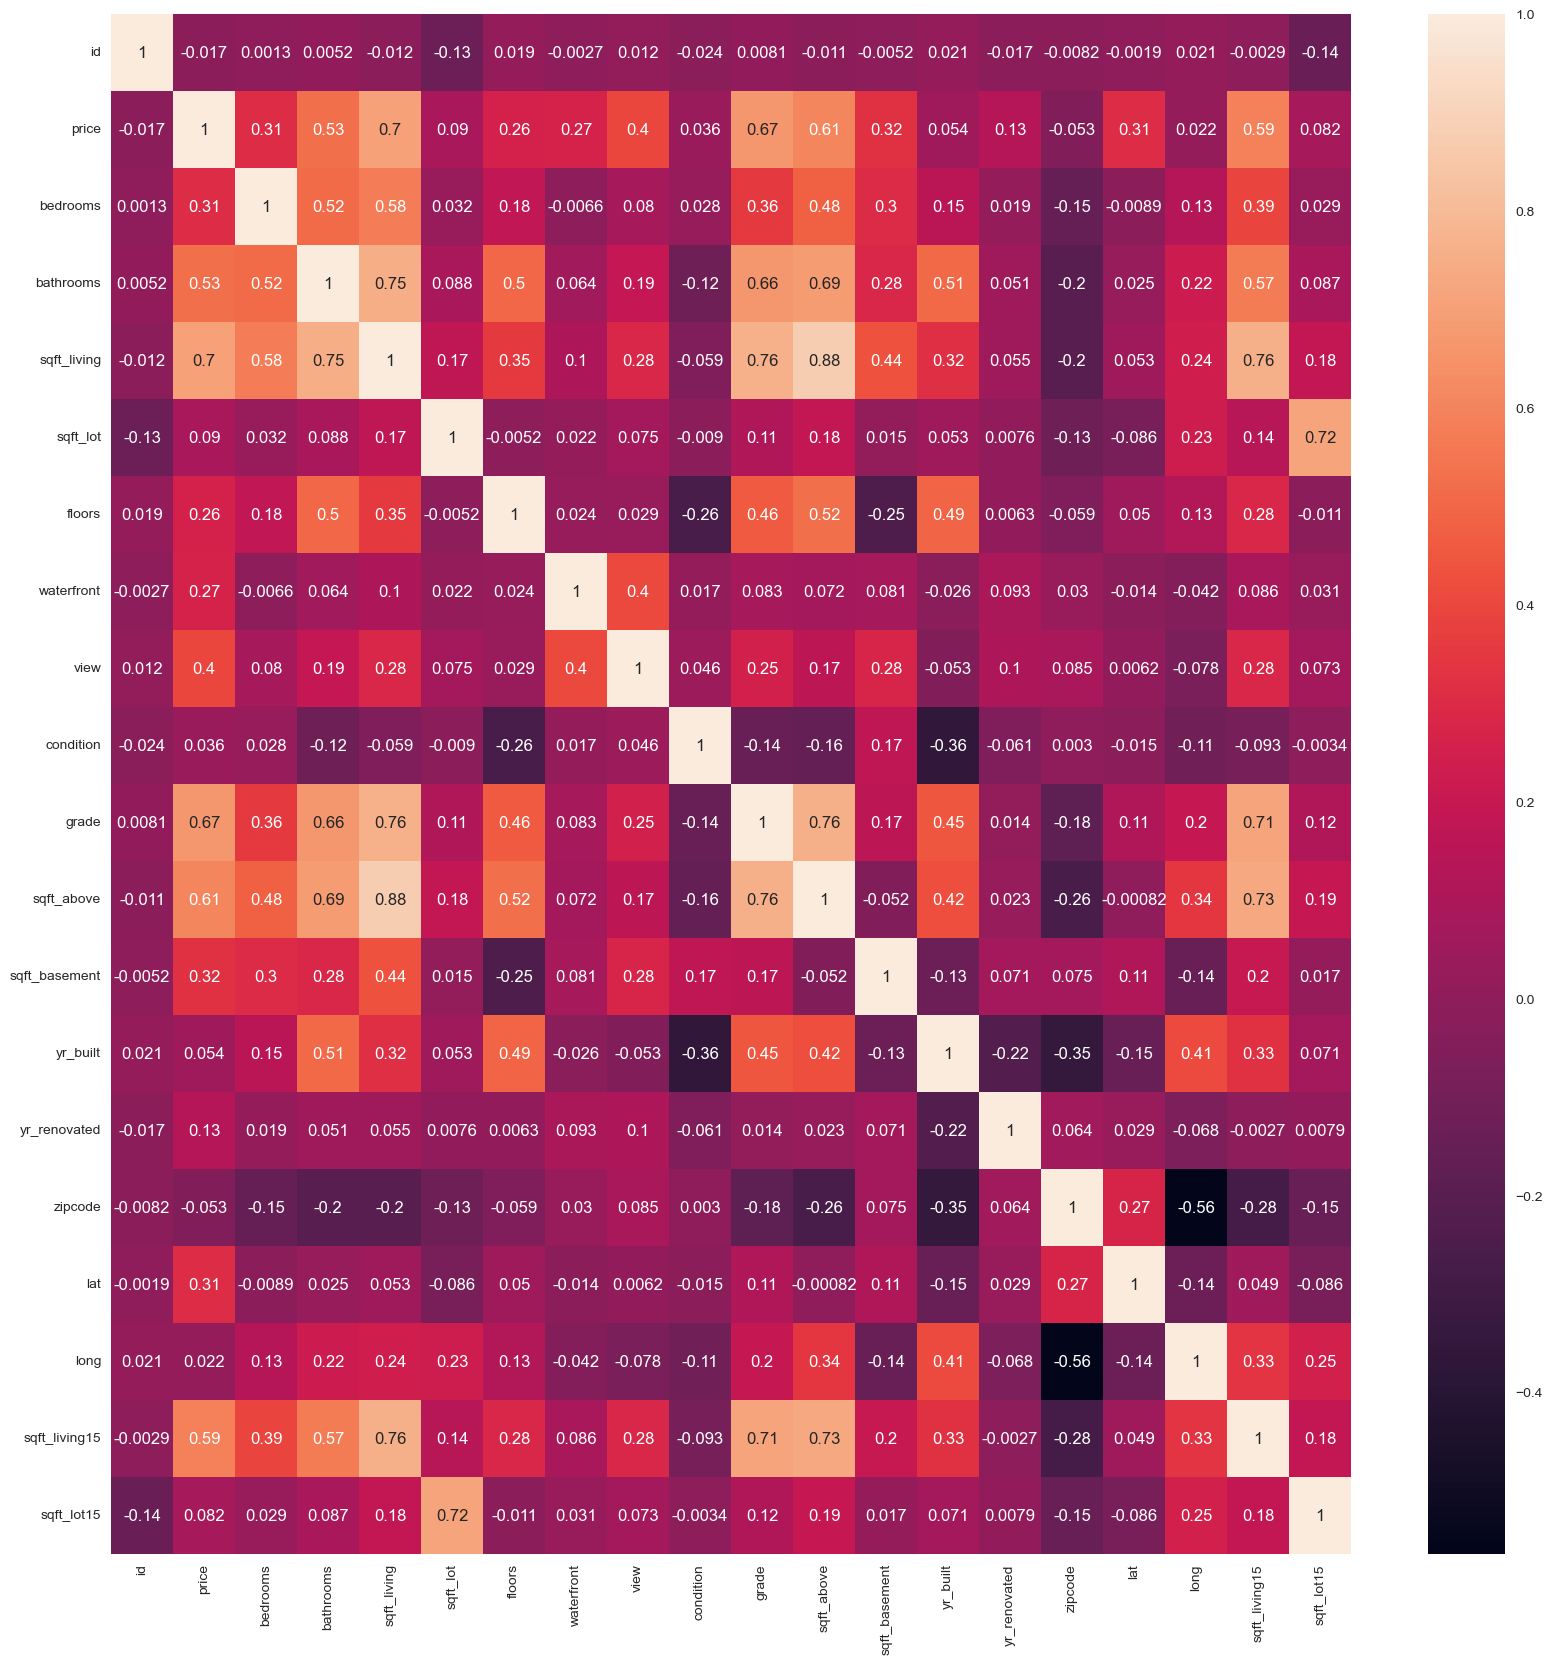

In [22]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [23]:
abs(df.corr(numeric_only=True)['price'].sort_values(ascending=False))

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id               0.016762
zipcode          0.053203
Name: price, dtype: float64

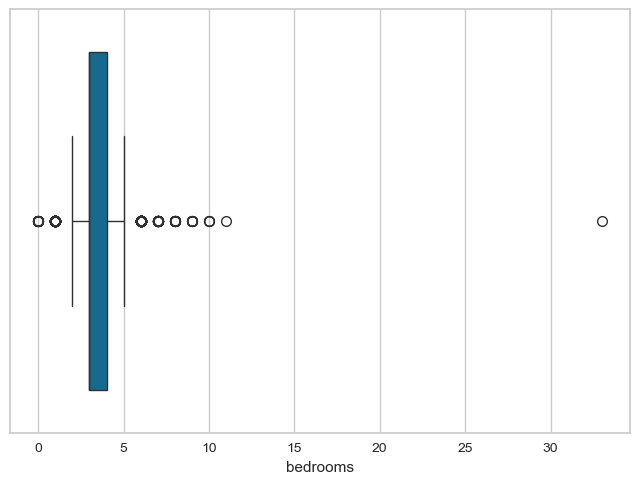

In [24]:
sns.boxplot(x=df['bedrooms']);

In [25]:
df['bedrooms'].mean()+3*df['bedrooms'].std()

6.1610271165395645

In [26]:
df[df['bedrooms']>30] 

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


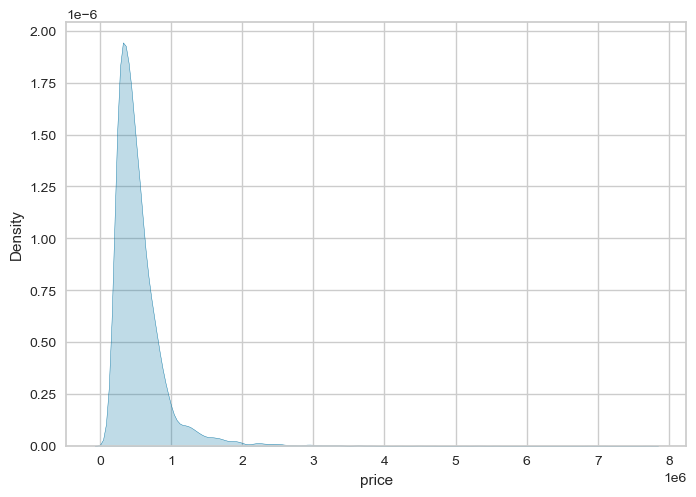

In [27]:
sns.kdeplot(x=df['price'],fill=True);

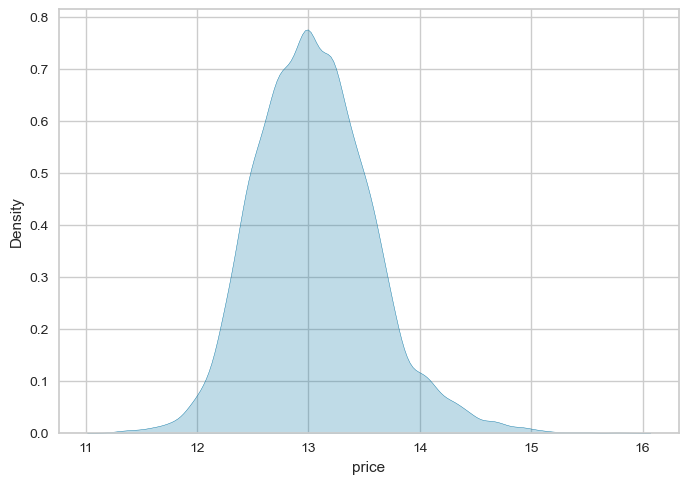

In [28]:
sns.kdeplot(x=np.log(df['price']),fill=True);

In [29]:
outliers=df.quantile(q=.97,numeric_only=True)

In [30]:
df=df[(df['price']<outliers['price'])]
df=df[(df['bedrooms']<outliers['bedrooms'])]
df=df[(df['bathrooms']<outliers['bathrooms'])]
df=df[(df['sqft_living']<outliers['sqft_living'])]

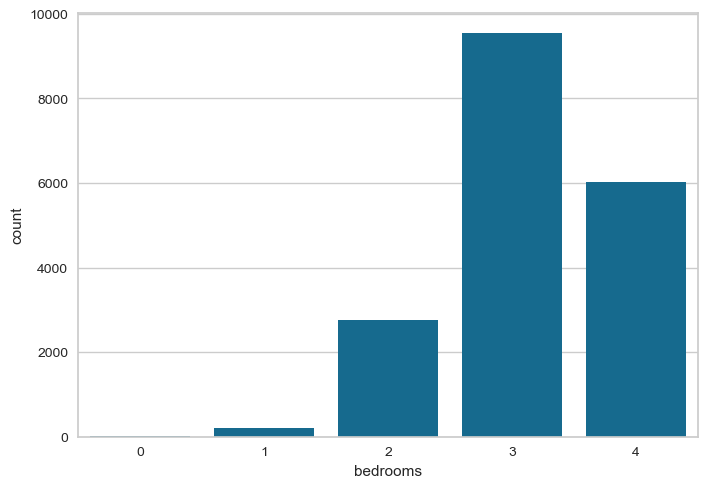

In [31]:
sns.countplot(x=df['bedrooms']);

### Feature Engineering

In [32]:
df['zipcode']=df['zipcode'].astype('object') 

In [33]:
# We increase the importance of these features by assigning them higher weight in the model.
df['bedrooms']=df['bedrooms']**2
df['bathrooms']=df['bathrooms']**2
df['sqft_living']=df['sqft_living']**2

In [34]:
import datetime

In [35]:
df['age']=datetime.datetime.now().year-df['yr_built'] # We are creating the age of the house as a new feature.

In [36]:
df['yr_renovated'] = np.where(df['yr_renovated'] > 1, 1, 0)  # 1 if renovated, 0 otherwise
df['sqft_basement'] = np.where(df['sqft_basement'] > 1, 1, 0)  # 1 if basement exists, 0 otherwise

### Modelling 

In [37]:
setup(df,target='price',session_id=123)

,Description,Value
0,Session id,123
1,Target,price
2,Target type,Regression
3,Original data shape,"(18519, 22)"
4,Transformed data shape,"(18519, 22)"
5,Transformed train set shape,"(12963, 22)"
6,Transformed test set shape,"(5556, 22)"
7,Numeric features,19
8,Categorical features,2
9,Preprocess,True


In [38]:
best_model=compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,52657.3530,6004555162.2227,77456.1478,0.8707,0.1645,0.1221,1.0280
et,Extra Trees Regressor,55059.3790,6726838449.2612,81977.7246,0.8552,0.1732,0.1272,0.7240
gbr,Gradient Boosting Regressor,57475.8463,6955000700.7734,83340.2040,0.8503,0.1755,0.1330,0.4070
rf,Random Forest Regressor,55928.3194,6967850143.5583,83400.3963,0.8500,0.1745,0.1291,1.4040
lr,Linear Regression,68235.7208,9177029711.3198,95741.0285,0.8026,0.2099,0.1582,0.4600
lasso,Lasso Regression,68235.3866,9177042745.5007,95741.0757,0.8026,0.2098,0.1582,0.2850
ridge,Ridge Regression,68232.4725,9176853151.8224,95739.8316,0.8026,0.2098,0.1582,0.1950
llar,Lasso Least Angle Regression,68235.3847,9177042878.5986,95741.0763,0.8026,0.2098,0.1582,0.0280
br,Bayesian Ridge,68226.7860,9177598202.1553,95743.1145,0.8026,0.2096,0.1581,0.0270
lar,Least Angle Regression,68901.3830,9333563213.4462,96564.2478,0.7992,0.2419,0.1592,0.0310


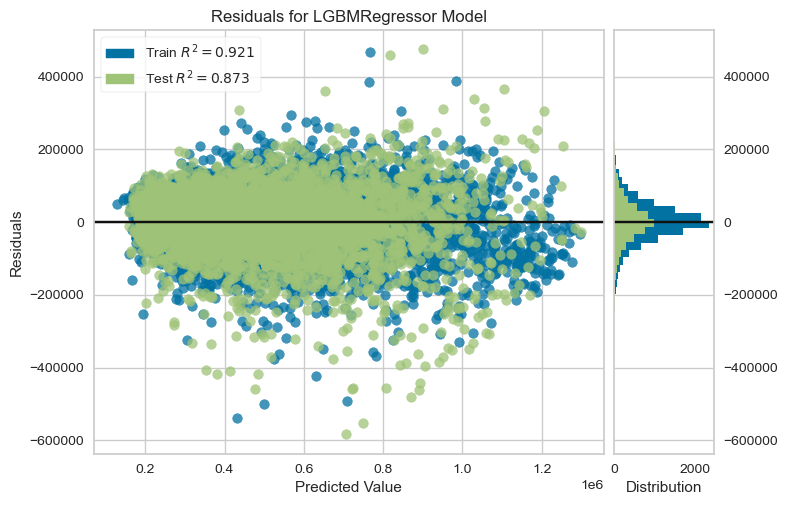

In [39]:
plot_model(best_model,plot='residuals')

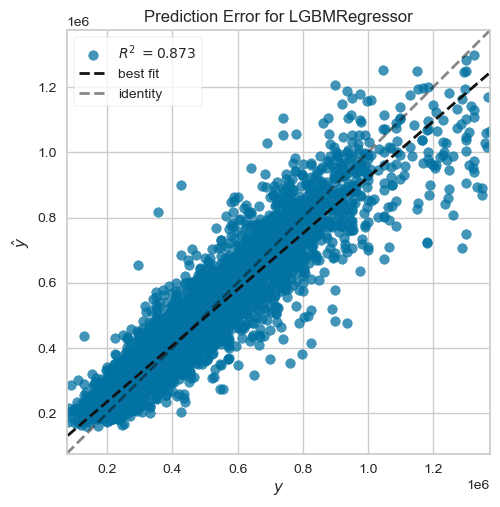

In [40]:
plot_model(best_model,plot='error')

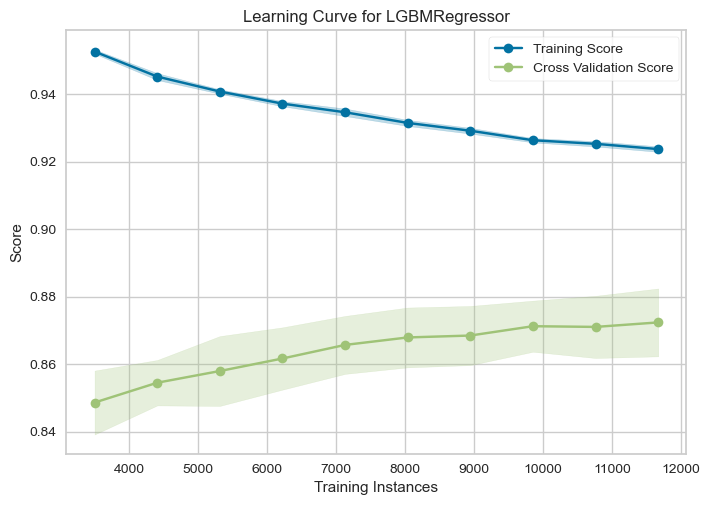

In [41]:
plot_model(best_model,plot='learning')

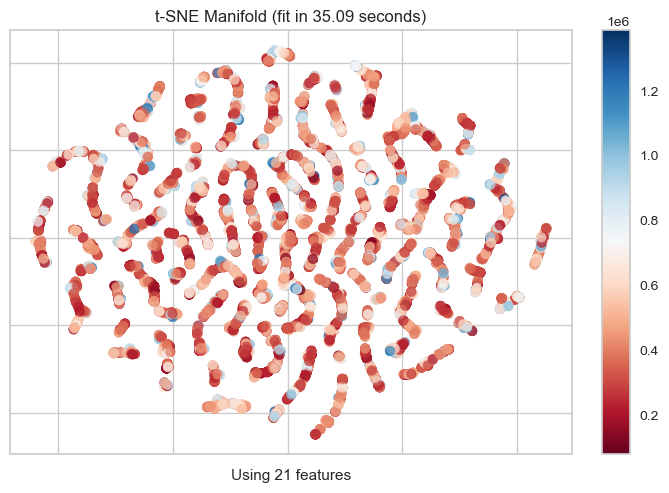

In [42]:
plot_model(best_model,plot='manifold')

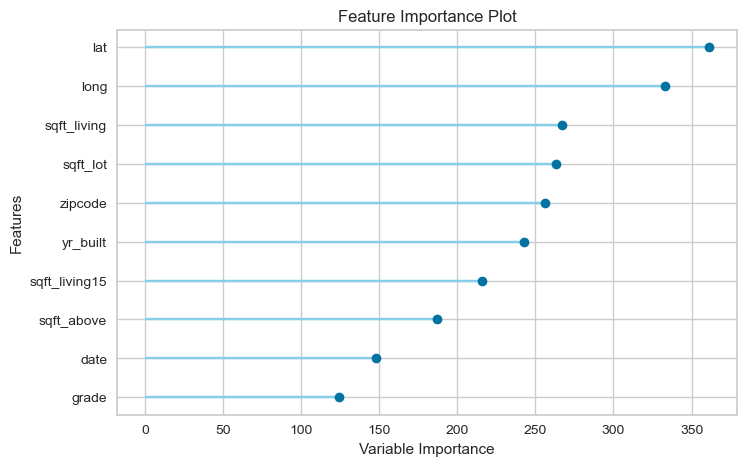

In [43]:
plot_model(best_model,plot='feature')

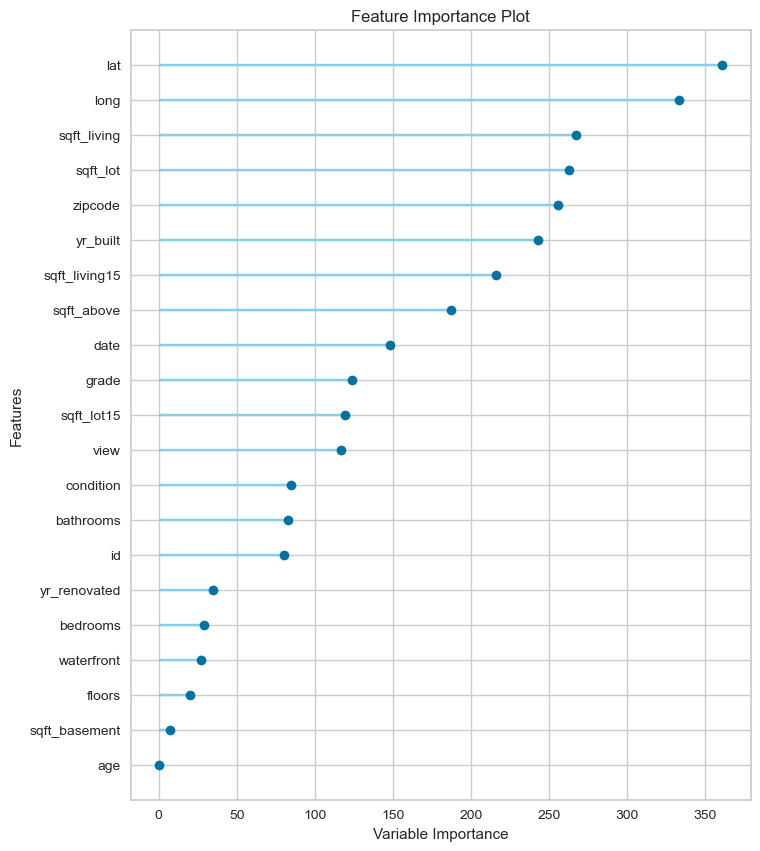

In [44]:
plot_model(best_model,plot='feature_all')

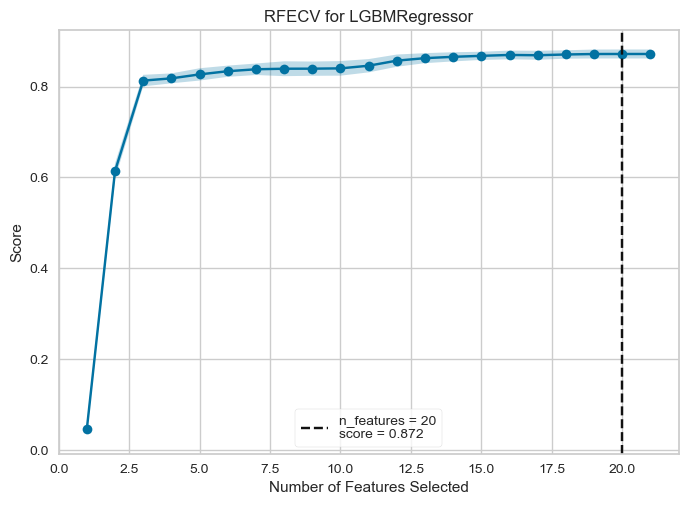

In [45]:
plot_model(best_model,plot='rfe')

## Conclusion

In this project, we applied Automated Machine Learning to efficiently compare a wide range of regression models for house price prediction. Among all models, **LightGBM** emerged as the top performer, achieving the highest R² score (~0.87) and the lowest error metrics.

Key takeaways:
- Tree-based ensemble models (LightGBM, Extra Trees, Random Forest) significantly outperformed linear models.
- The dataset’s rich feature set, especially size-related and location-based attributes, contributed strongly to predictive performance.
- Automated workflows enabled rapid experimentation and model comparison with minimal manual effort.

💡 **Insights:**
- Non-linear relationships dominate real estate pricing, making ensemble methods highly effective.
- Feature engineering and location-based features (lat, long, zipcode) play a crucial role.

Overall, this study demonstrates the power of Automated Machine Learning in quickly building strong baseline models and identifying high-performing algorithms in real-world regression problems.